Análisis de componentes principales PCA 

Reducción de las variables continuas a tan solo 3 variables, y como segundo caso a un cierto porcentaje elegido.
Datos adjuntos


---



BIBLIOTECAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import pearsonr

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°1 Regresión y MI/Aprendizaje_breast-cancer-wisconsin (1).tab', sep='\t')
df

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses,type,Selected
0,9.67,9.96,9.27,2.40,9.49,7.93,7.90,0.33,0.06,malign,No
1,0.14,0.15,0.47,0.82,1.71,0.19,2.22,0.55,0.49,benign,No
2,0.61,0.49,0.99,0.19,1.98,0.27,2.07,0.71,0.28,benign,No
3,7.29,1.11,3.42,0.07,4.63,0.25,4.17,3.76,3.11,malign,No
4,6.03,2.47,1.64,9.15,4.48,9.86,4.43,3.58,3.73,malign,No
...,...,...,...,...,...,...,...,...,...,...,...
578,5.00,4.92,4.65,5.29,2.63,9.22,2.81,0.78,0.13,malign,No
579,4.66,1.91,2.22,0.28,5.07,9.36,4.67,0.76,0.90,malign,No
580,2.90,0.77,0.24,3.74,2.32,0.23,1.19,1.12,0.94,benign,No
581,4.72,0.04,0.46,2.62,1.39,0.50,0.70,0.86,0.92,benign,No


El siguiente dataset llamado 'Aprendizaje_breast-cancer-wisconsin', ya trabajado anteriormente, cuenta con dierentes variables predictoras continuas X= {Clump thickness, Unif_Cell_Size,	Unif_Cell_Shape,	Marginal_Adhesion, .....} relacionadas a muestras biológicas, que buscan explicar la variable objetivo target 'y' categórica.

Por ejemplo, desde 'Clump thickness' hasta 'Mitoses', estas columnas corresponderian a medidas celulares que se utilizan comúnmente en la evaluación de muestras de tejido para el diagnóstico de cáncer. Cada una de estas medidas proporciona información sobre diferentes aspectos de las células, como su tamaño, forma, número de núcleos, entre otras.

En el caso de 'type', nos indicaría la clase o tipo de muestra, es decir, si es benigna (no cancerosa) o maligna (cancerosa). Esta columna sería nuestro target o 'y'.

Visualizamos rápidamente la distribución de los datos

In [ ]:
df.describe()

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,3.942899,2.643808,2.716123,2.320635,2.707616,3.073756,2.904734,2.315437,1.106106
std,2.839102,3.065228,3.002309,2.862875,2.195023,3.653948,2.384558,2.982279,1.754511
min,0.010000,0.000000,0.000000,0.000000,0.020000,0.000000,0.010000,0.010000,0.000000
25%,1.680000,0.460000,0.470000,0.410000,1.360000,0.450000,1.195000,0.425000,0.310000
50%,3.540000,0.920000,0.990000,0.870000,1.780000,0.860000,2.200000,0.800000,0.600000
75%,5.340000,4.035000,4.445000,3.080000,3.335000,5.650000,3.970000,2.950000,0.900000
max,10.000000,9.990000,10.000000,9.980000,9.960000,9.990000,9.970000,10.000000,9.920000


Eliminamos la columna 'selected' ya que no sería de gran relevancia para este dataset

In [ ]:
columnas_eliminar = ['Selected']
df = df.drop(columns=columnas_eliminar, axis=1)
df

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses,type
0,9.67,9.96,9.27,2.40,9.49,7.93,7.90,0.33,0.06,malign
1,0.14,0.15,0.47,0.82,1.71,0.19,2.22,0.55,0.49,benign
2,0.61,0.49,0.99,0.19,1.98,0.27,2.07,0.71,0.28,benign
3,7.29,1.11,3.42,0.07,4.63,0.25,4.17,3.76,3.11,malign
4,6.03,2.47,1.64,9.15,4.48,9.86,4.43,3.58,3.73,malign
...,...,...,...,...,...,...,...,...,...,...
578,5.00,4.92,4.65,5.29,2.63,9.22,2.81,0.78,0.13,malign
579,4.66,1.91,2.22,0.28,5.07,9.36,4.67,0.76,0.90,malign
580,2.90,0.77,0.24,3.74,2.32,0.23,1.19,1.12,0.94,benign
581,4.72,0.04,0.46,2.62,1.39,0.50,0.70,0.86,0.92,benign


Como trabajaremos con las variables continuas x, procedemos a separar el df del target

In [ ]:
df_x = df.drop(columns='type')

df_x.head()

,Clump thickness,Unif_Cell_Size,Unif_Cell_Shape,Marginal_Adhesion,Single_Cell_Size,Bare_Nuclei,Bland_Chromatine,Normal_Nucleoli,Mitoses
0,9.67,9.96,9.27,2.40,9.49,7.93,7.90,0.33,0.06
1,0.14,0.15,0.47,0.82,1.71,0.19,2.22,0.55,0.49
2,0.61,0.49,0.99,0.19,1.98,0.27,2.07,0.71,0.28
3,7.29,1.11,3.42,0.07,4.63,0.25,4.17,3.76,3.11
4,6.03,2.47,1.64,9.15,4.48,9.86,4.43,3.58,3.73


Ahora procedemos a aplicar PCA

PCA - - ANÁLISIS DE LAS COMPONENTES PRINCIPALES

EL PCA es una técnica estadística de reducción  de dimensionalidad, cuyo objetivo principal es evidenciar cuál es el conjunto de variables (features) que generan mayor variabilidad. Para ello, transforma un conjunto de variables posiblemente correlacionadas en un número menor de variables linealmente independientes llamadas componentes principales.De esta manera, su objetivo es capturar la máxima varianza (qué tan dispersos están los datos respecto a su media - variabilidad) de los datos originales utilizando el menor número de dimensiones posible, permitiendo así simplificar el análisis sin perder información relevante.
Por otro lado, las nuevas variables obtenidas por PCA van a ser resultados de  combinaciones lineales de las originales

In [ ]:
from sklearn.decomposition import PCA

Como se nos pide reducir la dimensionalidad a solo 3 componentes principales, tenemos:

In [ ]:
pca_1 = PCA(n_components=3)

Procedemos a entrenar pca en las variables originales del dataframe.

In [ ]:
pca_1.fit(df_x)

PCA(n_components=3)

Visualizamos las componentes principales

In [ ]:
pca_1.components_

array([[ 0.29618955,  0.40599005,  0.39695433,  0.33295633,  0.24427714,
         0.45195476,  0.27854443,  0.34948906,  0.12388359],
       [-0.34064611, -0.23163786, -0.18301148,  0.25202304, -0.18364773,
         0.75950704,  0.03920319, -0.29275893, -0.18834332],
       [ 0.76886301, -0.05307079,  0.02814492, -0.38227664, -0.14370212,
         0.26932574, -0.12424506, -0.38134693, -0.0711099 ]])

Como podemos observar en la tabla, tenemos las reducción en 3 componentes principales (filas) que son combinación lineal de las originales. Asimismo, cada componente principal tiene 9 coeficientes (columnas) que representarian las 9 variables/features originales del dataframe. Con respecto a los valores que visualizamos, estos representan los pesos de cada variable original en la combinación lineal.

Por lo tanto, tenemos vectores propios (componentes principales), que geométricamente indican las direcciones de mayor a menor varianza. Con lo cual, cada fila va representar una dirección en el espacio original donde los datos tienen máxima varianza (la primera componente la máxima, la segunda la siguiente máxima ortogonal a la primera, etc.). Desde el punto de vista de las features, las nuevas variables (cada componente principal), son combinaciones lineales de las originales.

Ahora aplicamos la varianza para poder tener más información e interpretar mejor los ceficientes.

Porcentaje de la varianza total explicada por cada dirección o nueva feature, ordenadas de mayor a menor:

In [ ]:
pca_1.explained_variance_ratio_

array([0.68581194, 0.06809797, 0.06488611])

Como verificación, la suma de todas las varianzas debería ser igual/aproximado a 1:

In [ ]:
sum(pca_1.explained_variance_ratio_)

np.float64(0.8187960228075218)

Ahora con los datos de varianza explicada podemos hacer un análisis mucho más completo:

- PC1: 68.58% de la varianza total.

- PC2: 6.81% de la varianza total

- PC3: 6.49% de la varianza total

En relación a la componente principal 1, podemos ver que esta captura casi el 70% de toda la variabilidad de los datos. Esto es muy significativo , ya que es la que tiene mayor información/variabilidad y sugiere que existe un patron fuerte comun entre las 9 variables originales. En sintesis, la que predomina es la PC1 y es la que podemos elegir para realizar predicciones.

Otro aspecto a tener en cuenta es que hay una gran diferencia  entre PC1 y las demás componenetes principales, donde PC2 y PC3 sólo explican el 6.8% y 6.5% respectivamente del total de variabilidad de los datos.

En relación a la suma de todas las varianzas, obtenemos un 81.88%. Si bien no da exactamente igual a 1 ya que podría haber algún pequeño error de redondeo.

Tomando en cuenta todo lo anterior, podemos plantear que la reducción de dimensionalidad es efectiva. Con solo las 3 componentes principales, se está capturando el 82% de la varianza total, lo que implica una reducción dimensional eficiente (de 9 a 3 dimensiones, mantenemos la mayor parte de la información del dataframe).


Retomando a PC1, observamos que, además de explicar el 68.58% de la varianza,  todos sus coeficientes son positivos y similares entre si. Esto sugiere que las 9 variables originales del df tienden a moverse juntas en la misma dirección.

Como todas las variables son características morfológicas de células cancerosas, entonces PC1 representaría un 'índice de  tumor maligno/benigno'.
Por ello vemos que todas estas características tienden a aumentar juntas, lo cual es biológicamente coherente porque son indicadores que apuntan hacia malignidad/benignidad.

En cambio con PC2 y PC3 (6.81% y 6.49%) vemos que capturan variaciones más sutiles. Posiblemente sean diferentes "tipos" o "patrones" de malignidad, o variaciones independientes entre algunas características.

Con lo cual podriamos concluir que solo con PC1 podríamos clasificar bastante bien entre un tumor benigno/maligno.

Si aplicamos el método .transform, obtendremos los valores de las nuevas variables o features, en este caso elegimos sólo 3.




In [ ]:
X_nuevos_3 = pca_1.transform(df_x)

In [ ]:
X_nuevos_3

array([[ 1.17141268e+01, -1.40816081e+00,  4.71335926e+00],
       [-5.96117189e+00,  5.04994776e-01, -2.11229937e+00],
       [-5.59704019e+00,  1.01996140e-02, -1.55820737e+00],
       ...,
       [-3.87589904e+00, -1.74455255e-01, -1.34414253e+00],
       [-4.25376950e+00, -5.11329956e-01,  8.96084956e-01],
       [ 1.40411478e+01,  3.56748612e-01, -3.19170909e+00]])

Estas serían las nuevas variables obtenidas como combinación lineal de las originales.



---



Para elegir el porcentaje consideramos estos criterios:
Análisis de los datos actuales:
- PC1: 68.58%
- PC1 + PC2: 75.39%
- PC1 + PC2 + PC3: 81.88%

Ahora reducimos las variables continuas a un 75%. Este porcentaje lo elegimos en base a los resultados obtenidos anteriormente. Al elegir un 0.75 estaríamos seleccionando 2 componentes principales (reducimos de 9 a 2 dimensiones), conservamos información relevante y es ideal para visualización (gráficos 2D).

Para el cálculo empleamos ahora otra forma un poco más automática, donde a 'n_components' hay que pasar un valor entre 0 y 1 que corresponde al porcentaje de la varianza que queremos retener, por ejemplo 0.95;  y la opción 'svd_solver' = 'full'. Luego podemos aplicar el método fit_transform para que efectúe las dos operaciones juntas:

In [ ]:
pca_2 = PCA(n_components = 0.75, svd_solver = 'full')
X_pca_auto =pca_2.fit_transform(df_x)
X_pca_auto

array([[ 1.17141268e+01, -1.40816081e+00],
       [-5.96117189e+00,  5.04994776e-01],
       [-5.59704019e+00,  1.01996140e-02],
       ...,
       [-3.87589904e+00, -1.74455255e-01],
       [-4.25376950e+00, -5.11329956e-01],
       [ 1.40411478e+01,  3.56748612e-01]])

Estas serían las nuevas variables obtenidas como combinación lineal de las originales.

In [ ]:
pca_2.components_

array([[ 0.29618955,  0.40599005,  0.39695433,  0.33295633,  0.24427714,
         0.45195476,  0.27854443,  0.34948906,  0.12388359],
       [-0.34064611, -0.23163786, -0.18301148,  0.25202304, -0.18364773,
         0.75950704,  0.03920319, -0.29275893, -0.18834332]])

In [ ]:
pca_1.components_    # para ver el pca inial lo que obtuvimos

array([[ 0.29618955,  0.40599005,  0.39695433,  0.33295633,  0.24427714,
         0.45195476,  0.27854443,  0.34948906,  0.12388359],
       [-0.34064611, -0.23163786, -0.18301148,  0.25202304, -0.18364773,
         0.75950704,  0.03920319, -0.29275893, -0.18834332],
       [ 0.76886301, -0.05307079,  0.02814492, -0.38227664, -0.14370212,
         0.26932574, -0.12424506, -0.38134693, -0.0711099 ]])

Como podemos ver, con pca_2 = PCA(n_components = 0.75, svd_solver = 'full') se redujo a solo dos componentes principales al aplicar un porcentaje de 0.75%. De esta manera visualizamos solo dos vectores propios (componentes principales), que geométricamente indican las direcciones de mayor a menor varianza.

Ahora si vemos el porcentaje de la varianza total explicada por cada dirección o nueva feature, ordenadas de mayor a menor, tenemos:

In [ ]:
pca_2.explained_variance_ratio_

array([0.68581194, 0.06809797])

In [ ]:
sum(pca_2.explained_variance_ratio_)

np.float64(0.7539099096132889)

Como podemos ver ahora solo con dos componentes principales  estamos capturando el 75% de la varianza total.
, lo que implica una reducción dimensional eficiente (de 9 a 2 dimensiones, mantenemos la mayor parte de la información del dataframe).

Finalmente pudimos obtener consistencia en el proceso, ya que los componentes que obtuvimos (de PC1 aplicando 0.75%) son idénticos a los del análisis anterior, confirmando que el método funciona correctamente.

De esta manera, se logró una reducción dimensional eficiente de 9 a 2 dimensiones, conservamos información al mantener el 75% de la variabilidad original y por último, logramos simplificación ya que ahora podemos trabajar con solo 2 variables en lugar de 9 y graficarlas.

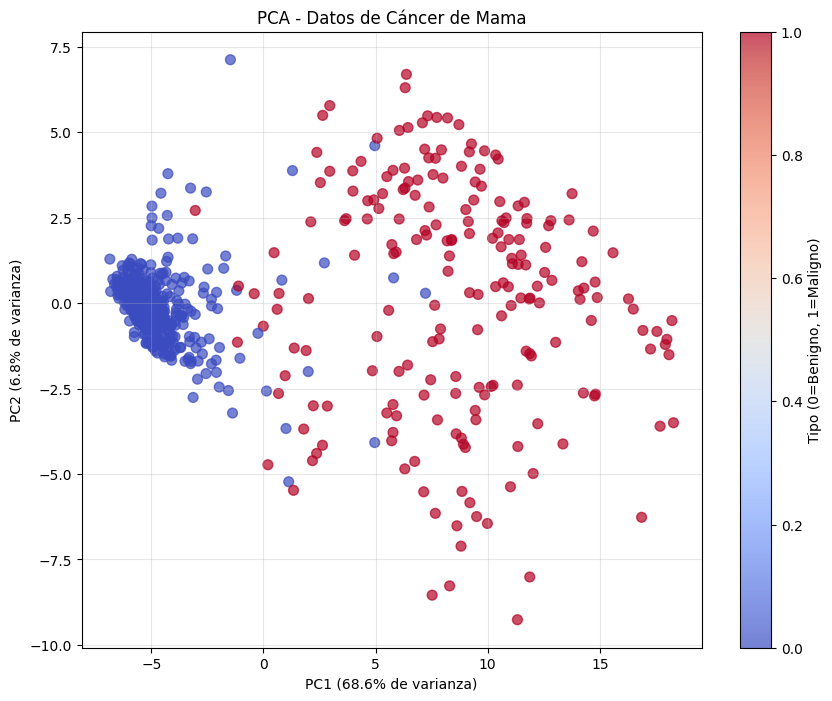

In [ ]:
# Gráfico
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_auto[:, 0], X_pca_auto[:, 1],
           c=df['type'].map({'benign': 0, 'malign': 1}),
           cmap='coolwarm', alpha=0.7, s=50)
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.1%} de varianza)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.1%} de varianza)')
plt.title('PCA - Datos de Cáncer de Mama')
plt.colorbar(label='Tipo (0=Benigno, 1=Maligno)')
plt.grid(True, alpha=0.3)
plt.show()

En el gráfico podemos visualizar de forma clara la separación de las clases:
- Azul (Benigno): los puntos azules vemos que se concentran principalmente en la izquierda.

- Rojo (Maligno): los puntos rojos se distribuyen más hacia el centro y  derecha (valores positivos de PC1).

También podemos confirmar a  PC1 como "índice de malignidad", ya que PC1 funciona perfectamente como diferenciador:
- Valores bajos de PC1 tenemos que es más 'Benigno'.
- Valores altos de PC1 = 'Maligno'.

Esto muestra que PC1 captura efectivamente al conjunto de características biológicas anormales que indican qué tan alteradas están las células respecto a células normales y sanas.

Por otra parte, vemos que se logró cierta efectividad en la reducción dimensional, donde con solo 2 dimensiones (75% de varianza) se logra una separación visual muy clara. La mayoría de los casos se pueden clasificar correctamente solo mirando PC1.

Concluyendo, podemos afirmar que se logró un PCA eficiente, una visualizacion clara permitiendo ver patrones que serían imposibles con 9 dimensiones y una base sólida para entrenar modelos de clasificación al contar con 2 componentes bien representativas.